In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving FIFA - World Cup Summary.csv to FIFA - World Cup Summary.csv


In [ ]:
df = pd.read_csv("FIFA - World Cup Summary.csv")

In [ ]:
df.head(10)

,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,Uruguay,Uruguay,Argentina,United States,13,16,70,3.6
1,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
2,1938,France,Italy,Hungary,Brazil,15,18,84,4.7
3,1950,Brazil,Uruguay,Brazil,Sweden,13,22,88,4.0
4,1954,Switzerland,West Germany,Hungary,Austria,16,26,140,5.4
5,1958,Sweden,Brazil,Sweden,France,16,35,126,3.6
6,1962,Chile,Brazil,Czechoslovakia,Chile,16,32,89,2.8
7,1966,England,England,West Germany,Portugal,16,32,89,2.8
8,1970,Mexico,Brazil,Italy,West Germany,16,32,95,3.0
9,1974,West Germany,West Germany,Netherlands,Poland,16,38,97,2.6


In [ ]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 21
Columns : 9


In [ ]:
df.columns

Index(['YEAR', 'HOST', 'CHAMPION', 'RUNNER UP', 'THIRD PLACE', 'TEAMS',
       'MATCHES PLAYED', 'GOALS SCORED', 'AVG GOALS PER GAME'],
      dtype='object')

In [ ]:
data = df[[
    'YEAR',
    'TEAMS',
    'MATCHES PLAYED',
    'GOALS SCORED',
    'AVG GOALS PER GAME'
]]

data.head()

,YEAR,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,13,16,70,3.6
1,1934,16,17,70,4.1
2,1938,15,18,84,4.7
3,1950,13,22,88,4.0
4,1954,16,26,140,5.4


In [ ]:
data = data.dropna()

print("Null Values Removed Successfully")


Null Values Removed Successfully


In [ ]:
data.head()


,YEAR,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,13,16,70,3.6
1,1934,16,17,70,4.1
2,1938,15,18,84,4.7
3,1950,13,22,88,4.0
4,1954,16,26,140,5.4


In [ ]:
# 'overall' column does not exist in the current DataFrame.
# Assuming 'GOALS SCORED' as a potential target variable for a regression task.
X = data.drop("GOALS SCORED", axis=1)
y = data["GOALS SCORED"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)


Training Data : (16, 4)
Testing Data : (5, 4)


In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
predictions = model.predict(X_test)

predictions[:10]

array([ 87.5 , 150.42, 154.62,  89.49,  91.55])

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 12.047999999999996
Mean Squared Error : 195.60267999999994
Root Mean Squared Error : 13.985802801412579
R2 Score : 0.885118004980501


In [ ]:
results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": predictions
})

results.head(20)

,Actual Rating,Predicted Rating
0,70,87.50
1,147,150.42
2,171,154.62
3,70,89.49
4,95,91.55


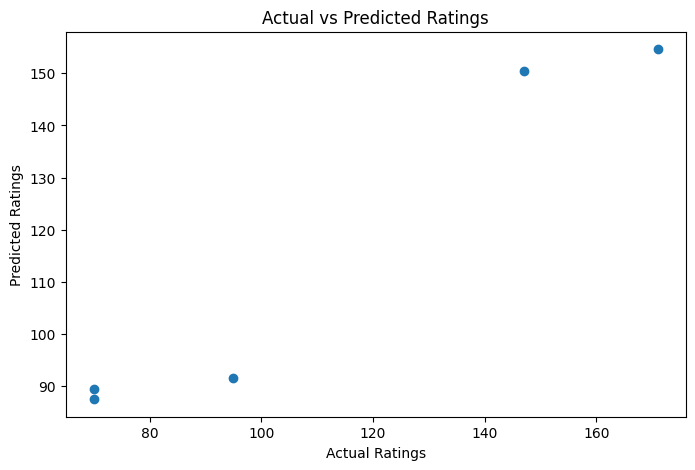

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

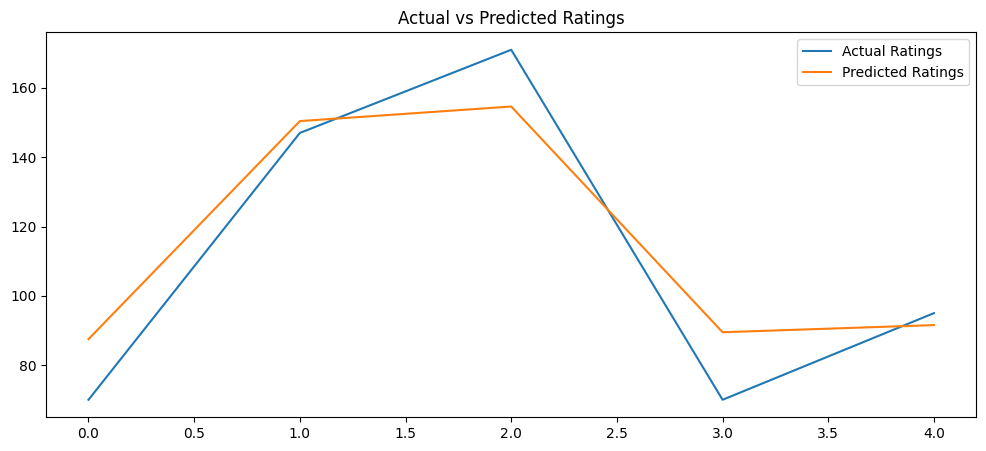

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label='Actual Ratings'
)

plt.plot(
    predictions[:100],
    label='Predicted Ratings'
)

plt.legend()

plt.title("Actual vs Predicted Ratings")

plt.show()

In [ ]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
0,YEAR,0.361557
2,MATCHES PLAYED,0.281393
1,TEAMS,0.205560
3,AVG GOALS PER GAME,0.151490


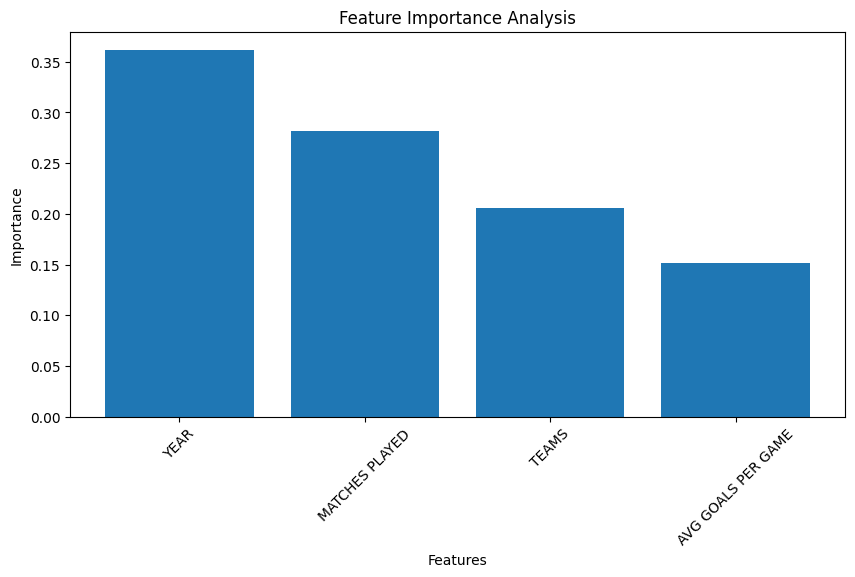

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance Analysis")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()


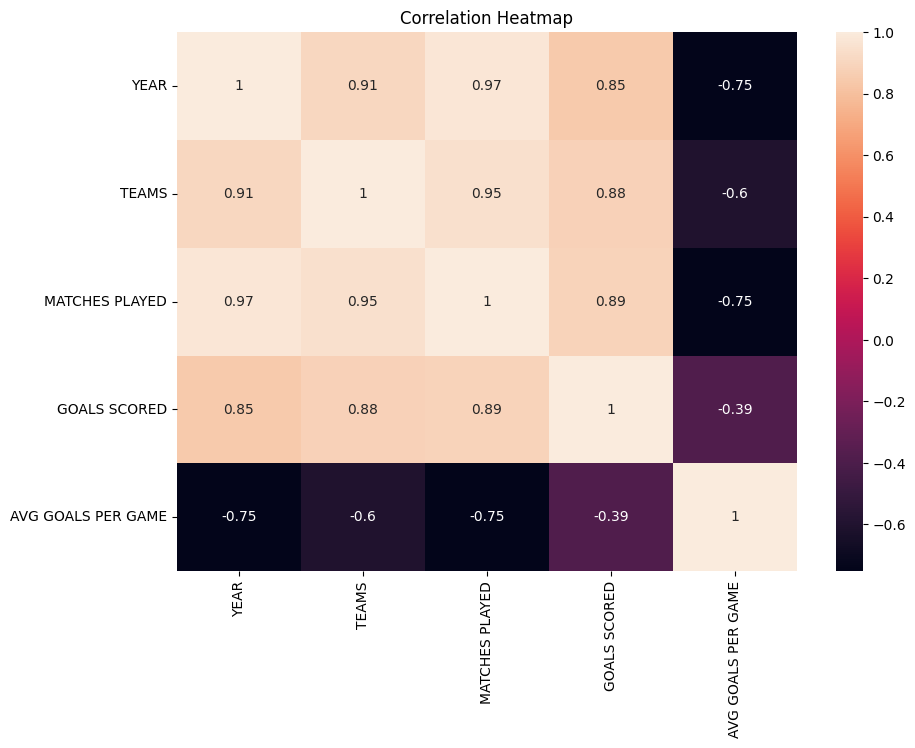

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    data.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

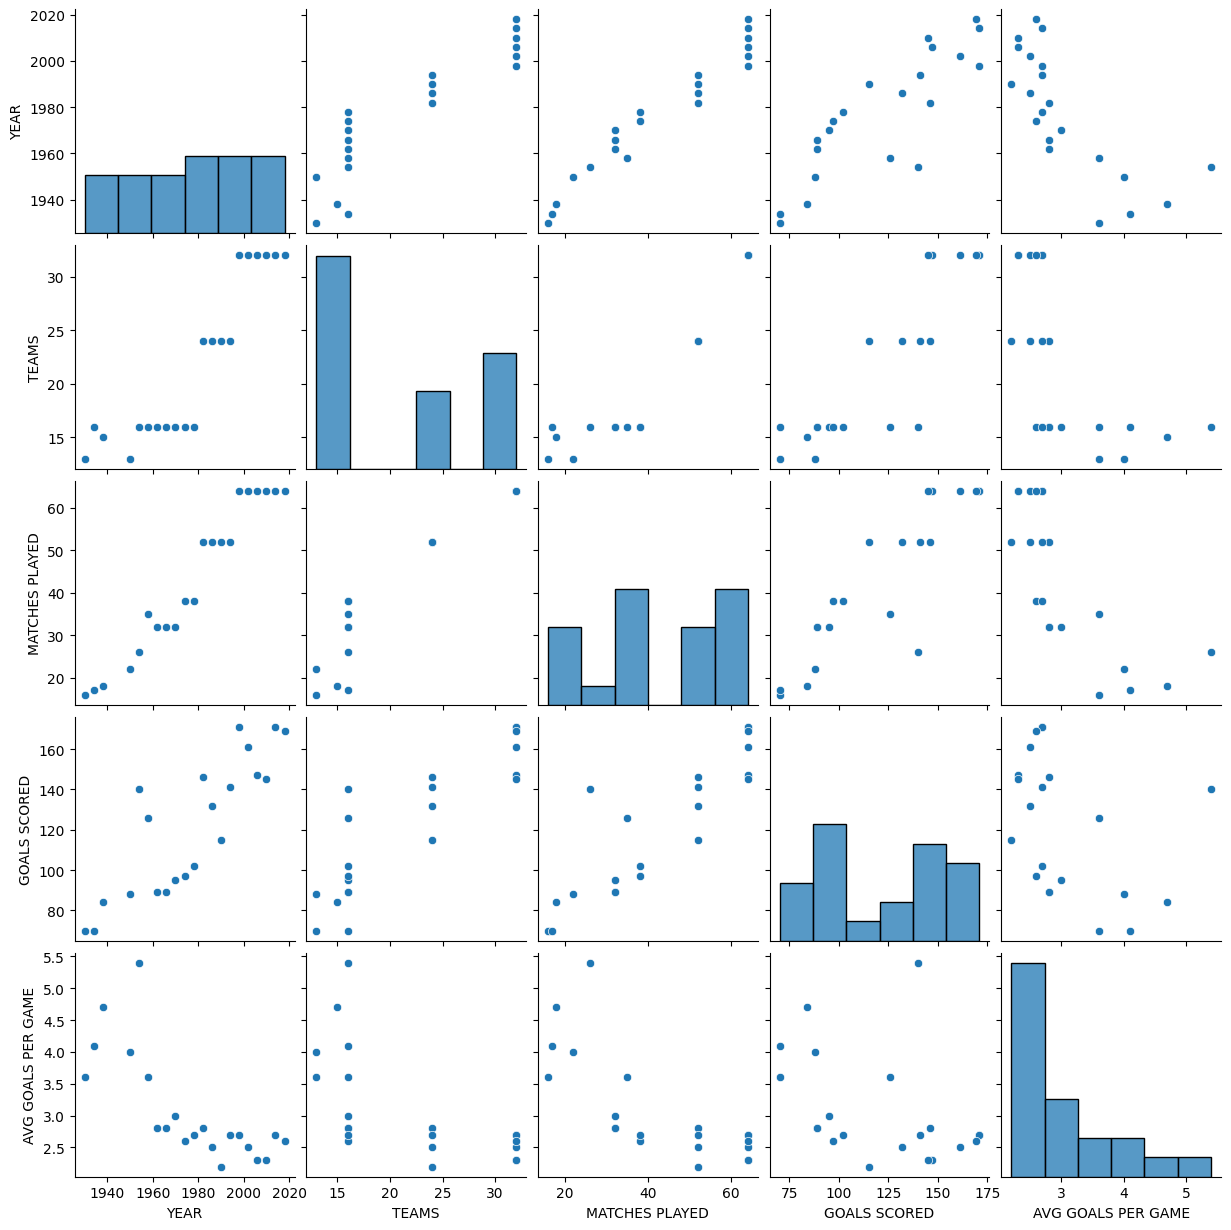

In [ ]:
sns.pairplot(
    data[[
        'YEAR',
        'TEAMS',
        'MATCHES PLAYED',
        'GOALS SCORED',
        'AVG GOALS PER GAME'
    ]]
)

plt.show()

In [ ]:
# The model was trained on 4 features: 'YEAR', 'TEAMS', 'MATCHES PLAYED', 'AVG GOALS PER GAME'
# Example: Predicting for a World Cup in 2026, with 32 teams, 64 matches, and an average of 2.5 goals per game
new_data = [[2026, 32, 64, 2.5]]

prediction = model.predict(new_data)

print("Predicted GOALS SCORED :", prediction[0])

Predicted GOALS SCORED : 164.63


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
